# Media Sentiment + Mean-Reversion Backtest Study

**Purpose:** Research whether daily / rolling media sentiment scores can improve (or harm) our existing Z-score mean-reversion system — **without changing the live Streamlit app**.

**Baseline strategy** (matches `app.py` / production notebooks):
- **Entry:** Z-score < -1.5
- **Stop:** trail = Close − 2×ATR (only raised)
- **Exit:** trailing stop hit **or** Z > 0
- Optional technical filter: Close > 50-SMA (for comparison)

**Media layer (research only):**
- Scores on Alpha Vantage NEWS_SENTIMENT scale **[-1, +1]**
- Aggregates: raw daily, **7d**, **30d**, Good/Neutral/Bad badges
- Default source: **reproducible simulator** (so the notebook runs offline)
- Swap path documented for real AV history dumps later

**Universe:** NVDA, META, NET, NOW, MSFT, GOOGL, PANW, CRWD, DDOG, CRM

---
Modular code lives in `studies/media_backtest_lib.py` so you can import the same engine into other notebooks.


## 0. Setup

Adds the project root to `sys.path`, imports the library, and sets plotting defaults.


In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Project root (parent of studies/)
ROOT = Path.cwd()
if ROOT.name == "studies":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from studies.media_backtest_lib import (
    UNIVERSE,
    START_CAPITAL,
    Z_ENTRY,
    ATR_MULT,
    prepare_frame,
    run_backtest,
    filter_always_ok,
    default_variant_specs,
    run_multi_variant_study,
    rank_variants,
    portfolio_equal_weight_equity,
    media_forward_correlation,
    vol_regime_trade_stats,
    threshold_sweep,
    summarize_trades,
    split_period_metrics,
    print_performance_block,
    plot_equity_vs_buyhold,
    plot_variant_equities,
    plot_threshold_sweep,
)

# Match testing-notebook matplotlib defaults
plt.rcParams.update({
    "figure.figsize": (14, 7),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

print("Universe:", ", ".join(UNIVERSE))
print(f"Baseline: Z < {Z_ENTRY} | {ATR_MULT}xATR trail | Z > 0 exit")
print(f"Start capital per name: ${START_CAPITAL:,.0f}")


Universe: NVDA, META, NET, NOW, MSFT, GOOGL, PANW, CRWD, DDOG, CRM
Baseline: Z < -1.5 | 2.0xATR trail | Z > 0 exit
Start capital per name: $1,000


## 1. Config

Adjust dates / capital here. Media is simulated by default so the study is fully runnable offline.


In [3]:
# ====================== STUDY CONFIG ======================
START_DATE = "2020-01-01"
END_DATE = None          # None = through latest available
SPLIT_DATE = "2025-01-01"  # regime split for period analysis
TICKERS = list(UNIVERSE)

# When you archive real historical media CSVs, load them via section 12.
USE_SIMULATED_MEDIA = True

print("Tickers:", TICKERS)
print("Window:", START_DATE, "->", END_DATE or "latest")
print("Regime split:", SPLIT_DATE)
print("Media source:", "SIMULATED (reproducible)" if USE_SIMULATED_MEDIA else "REAL")


Tickers: ['NVDA', 'META', 'NET', 'NOW', 'MSFT', 'GOOGL', 'PANW', 'CRWD', 'DDOG', 'CRM']
Window: 2020-01-01 -> latest
Regime split: 2025-01-01
Media source: SIMULATED (reproducible)


## 2. Sanity-check one name (NOW)

Reproduce baseline trade stats and preview media columns.


WINNING STRATEGY: Z < -1.5 + 2.0×ATR Trailing Stop
Starting Capital : $1,000
Final Value      : $3,002
Total Return     : 200.2%
CAGR             : 18.3%
Max Drawdown     : -40.9%
Number of Trades : 60

Trade Summary:
  Win rate       : 70.0%
  Avg trade      : 2.12%
  Avg winner     : 6.22%
  Avg loser      : -7.43%
  Avg days held  : 10.9

Last 8 trades:
entry_date  exit_date  entry_price  exit_price  return_pct  days_held
2025-12-15 2026-01-08      153.040     146.190      -4.476         24
2026-01-09 2026-01-14      141.800     134.610      -5.071          5
2026-01-15 2026-01-29      131.170     116.730     -11.009         14
2026-01-30 2026-02-05      117.010     102.630     -12.290          6
2026-02-06 2026-02-26      100.740     109.300       8.497         20
2026-03-24 2026-04-09      104.650      89.810     -14.181         16
2026-04-10 2026-04-20       83.000      99.720      20.145         10
2026-04-23 2026-05-07       84.780      93.590      10.392         14


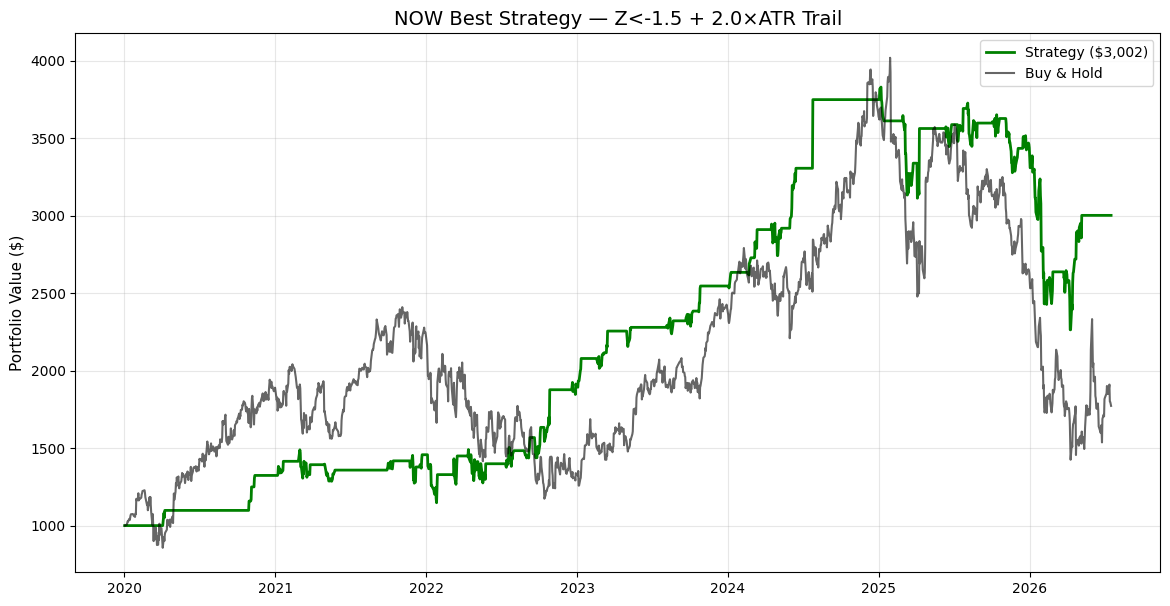

In [4]:
demo_ticker = "NOW"
df_now = prepare_frame(demo_ticker, start=START_DATE, end=END_DATE)
assert df_now is not None, "Failed to download NOW"

# ----- Baseline backtest (Z < -1.5 + 2×ATR trail, exit Z > 0) -----
base = run_backtest(
    df_now, ticker=demo_ticker, variant="baseline", entry_filter=filter_always_ok
)

# Unpack to the same variable names as testing/test2.ipynb
data = base.daily
final_value = base.metrics["final_equity"]
cagr = base.metrics["cagr"]
max_dd = base.metrics["max_dd"]
trades_df = base.trades
trades = trades_df.to_dict("records") if trades_df is not None else []

# ========== Performance (exact testing-notebook layout) ==========
print("=" * 60)
print(f"WINNING STRATEGY: Z < {Z_ENTRY} + {ATR_MULT}×ATR Trailing Stop")
print("=" * 60)
print(f"Starting Capital : ${START_CAPITAL:,.0f}")
print(f"Final Value      : ${final_value:,.0f}")
print(f"Total Return     : {(final_value / START_CAPITAL - 1) * 100:.1f}%")
print(f"CAGR             : {cagr * 100:.1f}%")
print(f"Max Drawdown     : {max_dd * 100:.1f}%")
print(f"Number of Trades : {len(trades)}")
print("=" * 60)

if trades_df is not None and len(trades_df) > 0:
    print("\nTrade Summary:")
    print(f"  Win rate       : {(trades_df['return_pct'] > 0).mean() * 100:.1f}%")
    print(f"  Avg trade      : {trades_df['return_pct'].mean():.2f}%")
    print(f"  Avg winner     : {trades_df.loc[trades_df['return_pct'] > 0, 'return_pct'].mean():.2f}%")
    print(f"  Avg loser      : {trades_df.loc[trades_df['return_pct'] <= 0, 'return_pct'].mean():.2f}%")
    print(f"  Avg days held  : {trades_df['days_held'].mean():.1f}")
    print("\nLast 8 trades:")
    show_cols = [
        c
        for c in [
            "entry_date",
            "exit_date",
            "entry_price",
            "exit_price",
            "return_pct",
            "days_held",
        ]
        if c in trades_df.columns
    ]
    print(trades_df[show_cols].tail(8).to_string(index=False))

# ========== Equity curve (exact testing-notebook layout) ==========
plt.figure(figsize=(14, 7))
plt.plot(
    data["equity"],
    label=f"Strategy (${final_value:,.0f})",
    color="green",
    lw=2,
)
plt.plot(
    data.index,
    START_CAPITAL * (1 + data["daily_ret"].fillna(0)).cumprod(),
    label="Buy & Hold",
    color="black",
    alpha=0.6,
)
plt.title(
    f"{demo_ticker} Best Strategy — Z<{Z_ENTRY} + {ATR_MULT}×ATR Trail",
    fontsize=14,
)
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Variant catalog

Each variant keeps the **same** Z/ATR mechanics and only changes **whether an entry is allowed** when Z < -1.5.


In [6]:
variants = default_variant_specs()
print("Variants under test:")
for i, name in enumerate(variants, 1):
    print(f"  {i:2d}. {name}")

print(
    '''
Interpretation cheat-sheet
--------------------------
baseline              pure Z + ATR trail (live default without trend gate)
trend50               Close > 50-SMA (quality-style technical filter)
media7d_neutral+      7d media >= -0.15  (Neutral or better badge zone)
media7d_gt0           7d media > 0
media7d_gt015         7d media > 0.15 (Good zone)
media30d_*            same idea on 30d lookback
badge7d_not_bad       badge in {Good, Neutral}
badge7d_good_only     badge == Good only
avoid_earnings        skip entries near earnings window
media7d_gt0_no_earn   media > 0 AND not near earnings
composite_z_media     combine depth of Z with media_7d
trend50_media7d_gt0   technical trend + media
'''
)


Variants under test:
   1. baseline
   2. trend50
   3. media7d_neutral+
   4. media7d_gt0
   5. media7d_gt015
   6. media30d_neutral+
   7. media30d_gt0
   8. badge7d_not_bad
   9. badge7d_good_only
  10. avoid_earnings
  11. media7d_gt0_no_earn
  12. composite_z_media
  13. trend50_media7d_gt0

Interpretation cheat-sheet
--------------------------
baseline              pure Z + ATR trail (live default without trend gate)
trend50               Close > 50-SMA (quality-style technical filter)
media7d_neutral+      7d media >= -0.15  (Neutral or better badge zone)
media7d_gt0           7d media > 0
media7d_gt015         7d media > 0.15 (Good zone)
media30d_*            same idea on 30d lookback
badge7d_not_bad       badge in {Good, Neutral}
badge7d_good_only     badge == Good only
avoid_earnings        skip entries near earnings window
media7d_gt0_no_earn   media > 0 AND not near earnings
composite_z_media     combine depth of Z with media_7d
trend50_media7d_gt0   technical trend + media

## 4. Multi-stock × multi-variant backtest

Heavy cell: downloads each ticker once, then runs all variants.


In [7]:
summary, all_trades, frames = run_multi_variant_study(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    variants=variants,
    verbose=True,
)

print("\nSummary shape:", summary.shape)
print("Trades shape:", all_trades.shape)
summary.head(12)


[1/10] NVDA …
[2/10] META …
[3/10] NET …
[4/10] NOW …
[5/10] MSFT …
[6/10] GOOGL …
[7/10] PANW …
[8/10] CRWD …
[9/10] DDOG …
[10/10] CRM …

Summary shape: (130, 18)
Trades shape: (4146, 18)


,ticker,variant,final_equity,total_return_pct,cagr,max_dd,sharpe,bh_final,beats_bh,num_trades,win_rate,avg_trade_pct,avg_win_pct,avg_loss_pct,avg_days_held,fwd_5d_mean,fwd_10d_mean,fwd_21d_mean
0,NVDA,baseline,"4,597.547",359.755,0.263,-0.257,1.030,"34,006.814",False,51,0.745,3.276,6.690,-6.704,9.490,1.926,4.062,7.256
1,NVDA,trend50,"1,144.061",14.406,0.021,-0.193,0.235,"34,006.814",False,14,0.643,1.147,5.278,-6.289,9.214,-0.318,1.562,6.234
2,NVDA,media7d_neutral+,"3,198.866",219.887,0.195,-0.281,0.837,"34,006.814",False,47,0.723,2.745,6.392,-6.792,9.574,1.334,3.928,7.073
3,NVDA,media7d_gt0,"2,475.334",147.533,0.149,-0.335,0.695,"34,006.814",False,42,0.714,2.442,6.286,-7.166,9.476,1.835,3.705,6.378
4,NVDA,media7d_gt015,"1,924.739",92.474,0.105,-0.149,0.797,"34,006.814",False,14,0.786,5.134,8.658,-7.785,8.286,3.518,4.785,7.560
5,NVDA,media30d_neutral+,"4,445.896",344.590,0.256,-0.257,1.013,"34,006.814",False,50,0.740,3.273,6.779,-6.704,9.540,1.896,3.992,7.308
6,NVDA,media30d_gt0,"4,024.670",302.467,0.237,-0.193,1.052,"34,006.814",False,40,0.775,3.801,7.024,-7.300,8.875,2.565,5.774,8.557
7,NVDA,badge7d_not_bad,"3,198.866",219.887,0.195,-0.281,0.837,"34,006.814",False,47,0.723,2.745,6.392,-6.792,9.574,1.334,3.928,7.073
8,NVDA,badge7d_good_only,"1,924.739",92.474,0.105,-0.149,0.797,"34,006.814",False,14,0.786,5.134,8.658,-7.785,8.286,3.518,4.785,7.560
9,NVDA,avoid_earnings,"4,613.930",361.393,0.263,-0.225,1.042,"34,006.814",False,49,0.755,3.420,6.791,-6.976,9.837,1.947,4.439,7.692


## 5. Ranking tables

Cross-sectional average performance by variant (equal-weight across names).


In [8]:
ranking = rank_variants(summary)
print("=" * 100)
print("VARIANT RANKING (avg across tickers, by mean final equity)")
print("=" * 100)
display_cols = [
    "rank",
    "variant",
    "mean_final",
    "mean_cagr",
    "mean_max_dd",
    "mean_sharpe",
    "mean_win_rate",
    "total_trades",
    "mean_fwd_10d",
    "beats_bh_count",
    "tickers",
]
print(ranking[display_cols].to_string(index=False))

base_mean = ranking.loc[ranking["variant"] == "baseline", "mean_final"]
base_mean = float(base_mean.iloc[0]) if len(base_mean) else np.nan
ranking = ranking.copy()
ranking["delta_vs_baseline_$"] = ranking["mean_final"] - base_mean
print("\nDelta vs baseline (mean final $):")
print(
    ranking[["rank", "variant", "mean_final", "delta_vs_baseline_$", "total_trades"]].to_string(
        index=False
    )
)


VARIANT RANKING (avg across tickers, by mean final equity)
 rank             variant  mean_final  mean_cagr  mean_max_dd  mean_sharpe  mean_win_rate  total_trades  mean_fwd_10d  beats_bh_count  tickers
    1            baseline   2,693.035      0.153       -0.311        0.723          0.662           527         2.543               2       10
    2   composite_z_media   2,693.035      0.153       -0.311        0.723          0.662           527         2.543               2       10
    3      avoid_earnings   2,570.123      0.142       -0.295        0.690          0.661           498         2.478               2       10
    4   media30d_neutral+   2,361.846      0.125       -0.320        0.641          0.652           486         2.440               2       10
    5     badge7d_not_bad   2,293.326      0.126       -0.315        0.674          0.665           463         2.489               2       10
    6    media7d_neutral+   2,293.326      0.126       -0.315        0.674         

## 6. Per-ticker heat map (final equity by variant)


In [9]:
pivot_final = summary.pivot(index="ticker", columns="variant", values="final_equity")
ordered = [v for v in ranking["variant"].tolist() if v in pivot_final.columns]
pivot_final = pivot_final[ordered]
print("Final equity by ticker x variant")
print(pivot_final.round(0).to_string())

best_non_base = ranking.loc[ranking["variant"] != "baseline", "variant"]
if len(best_non_base):
    top_var = best_non_base.iloc[0]
    if "baseline" in pivot_final.columns and top_var in pivot_final.columns:
        lift = (pivot_final[top_var] - pivot_final["baseline"]).sort_values(ascending=False)
        print(f"\nLift vs baseline for top variant '{top_var}':")
        print(lift.round(0).to_string())


Final equity by ticker x variant
variant  baseline  composite_z_media  avoid_earnings  media30d_neutral+  badge7d_not_bad  media7d_neutral+  media30d_gt0  media7d_gt0  media7d_gt0_no_earn   trend50  trend50_media7d_gt0  badge7d_good_only  media7d_gt015
ticker                                                                                                                                                                                                                     
CRM     1,297.000          1,297.000       1,194.000          1,207.000        1,859.000         1,859.000     1,403.000    1,640.000            1,445.000 1,044.000            1,150.000            990.000        990.000
CRWD    1,793.000          1,793.000       1,272.000          1,544.000        1,198.000         1,198.000       887.000    1,395.000            1,418.000 1,143.000              970.000            931.000        931.000
DDOG    4,188.000          4,188.000       4,410.000          3,665.000        3,069.00

## 7. Trade-level diagnostics

Win rates, forward returns, exit reasons, media at entry.


In [10]:
if all_trades.empty:
    print("No trades generated.")
else:
    by_var = (
        all_trades.groupby("variant")
        .agg(
            n=("return_pct", "count"),
            win_rate=("return_pct", lambda s: (s > 0).mean()),
            avg_ret=("return_pct", "mean"),
            avg_win=("return_pct", lambda s: s[s > 0].mean()),
            avg_loss=("return_pct", lambda s: s[s <= 0].mean()),
            avg_hold=("days_held", "mean"),
            fwd5=("fwd_5d", "mean"),
            fwd10=("fwd_10d", "mean"),
            fwd21=("fwd_21d", "mean"),
            avg_media7=("entry_media_7d", "mean"),
        )
        .sort_values("avg_ret", ascending=False)
    )
    print("Trade stats by variant (pooled across tickers)")
    print(by_var.to_string())

    print("\nExit reason mix:")
    focus = [
        v
        for v in [
            "baseline",
            "media7d_gt0",
            "media7d_neutral+",
            "avoid_earnings",
            "composite_z_media",
        ]
        if v in all_trades["variant"].unique()
    ]
    for v in focus:
        sub = all_trades[all_trades["variant"] == v]
        print(f"\n{v} (n={len(sub)})")
        print(sub["exit_reason"].value_counts(normalize=True).mul(100).round(1).to_string())


Trade stats by variant (pooled across tickers)
                       n  win_rate  avg_ret  avg_win  avg_loss  avg_hold  fwd5  fwd10  fwd21  avg_media7
variant                                                                                                 
media7d_gt0          298     0.651    2.132    7.030    -7.005    10.262 1.946  2.765  4.302       0.104
trend50_media7d_gt0   47     0.660    2.111    5.808    -5.052     7.489 2.184  2.892  6.443       0.116
baseline             527     0.660    2.096    6.941    -7.323    10.507 1.571  2.489  4.149      -0.006
composite_z_media    527     0.660    2.096    6.941    -7.323    10.507 1.571  2.489  4.149      -0.006
avoid_earnings       498     0.659    2.059    6.880    -7.242    10.745 1.533  2.414  4.034      -0.004
media7d_gt0_no_earn  286     0.647    2.013    6.959    -7.047    10.364 1.842  2.760  4.185       0.107
badge7d_not_bad      463     0.663    2.003    6.855    -7.546    10.460 1.604  2.499  3.987       0.029
media7d_

## 8. Regime split (pre vs post `SPLIT_DATE`)

Does the media filter behave differently in 2020–2024 vs 2025+?


In [11]:
print("Regime split date:", SPLIT_DATE)

period_rows = []
for variant in summary["variant"].unique():
    tr = (
        all_trades[all_trades["variant"] == variant]
        if not all_trades.empty
        else pd.DataFrame()
    )
    if tr.empty:
        continue
    sp = split_period_metrics(tr, equity=pd.Series(dtype=float), split_date=SPLIT_DATE)
    if sp.empty:
        continue
    sp.insert(0, "variant", variant)
    period_rows.append(sp)

period_df = pd.concat(period_rows, ignore_index=True) if period_rows else pd.DataFrame()
if period_df.empty:
    print("No period stats.")
else:
    print(period_df.to_string(index=False))

for variant in ["baseline", "media7d_gt0", "media7d_neutral+", "trend50"]:
    if variant not in summary["variant"].values:
        continue
    sub = summary[summary["variant"] == variant]
    print(
        f"\n{variant}: mean CAGR {sub['cagr'].mean()*100:.1f}% | "
        f"mean DD {sub['max_dd'].mean()*100:.1f}% | trades {int(sub['num_trades'].sum())}"
    )


Regime split date: 2025-01-01
            variant    period  num_trades  win_rate  avg_trade_pct  fwd_5d_mean  fwd_10d_mean  fwd_21d_mean
           baseline  pre_2025         376     0.689          2.503        1.811         2.970         4.987
           baseline post_2025         151     0.589          1.083        0.973         1.291         2.020
            trend50  pre_2025          66     0.742          2.515        2.528         2.786         5.292
            trend50 post_2025          20     0.550         -0.165        0.190         1.172         1.178
   media7d_neutral+  pre_2025         328     0.692          2.418        1.963         3.029         4.867
   media7d_neutral+ post_2025         135     0.593          0.992        0.733         1.211         1.801
        media7d_gt0  pre_2025         214     0.696          2.612        2.338         3.308         4.738
        media7d_gt0 post_2025          84     0.536          0.910        0.946         1.383         3.17

## 9. Exploratory analysis — avenues to pursue


### 9a. Media vs forward returns (correlation)

If media has no correlation with forward returns, filters mainly act as **trade throttles** (fewer trades), not predictive edge. That can still be useful if it cuts losers.


Pooled correlation: media score vs forward returns
    media forward   corr     n
media_raw  fwd_5d -0.016 16130
media_raw fwd_10d -0.011 16130
media_raw fwd_21d  0.001 16130
 media_7d  fwd_5d -0.007 16130
 media_7d fwd_10d  0.004 16130
 media_7d fwd_21d  0.001 16130
media_30d  fwd_5d -0.009 16130
media_30d fwd_10d -0.011 16130
media_30d fwd_21d -0.018 16130


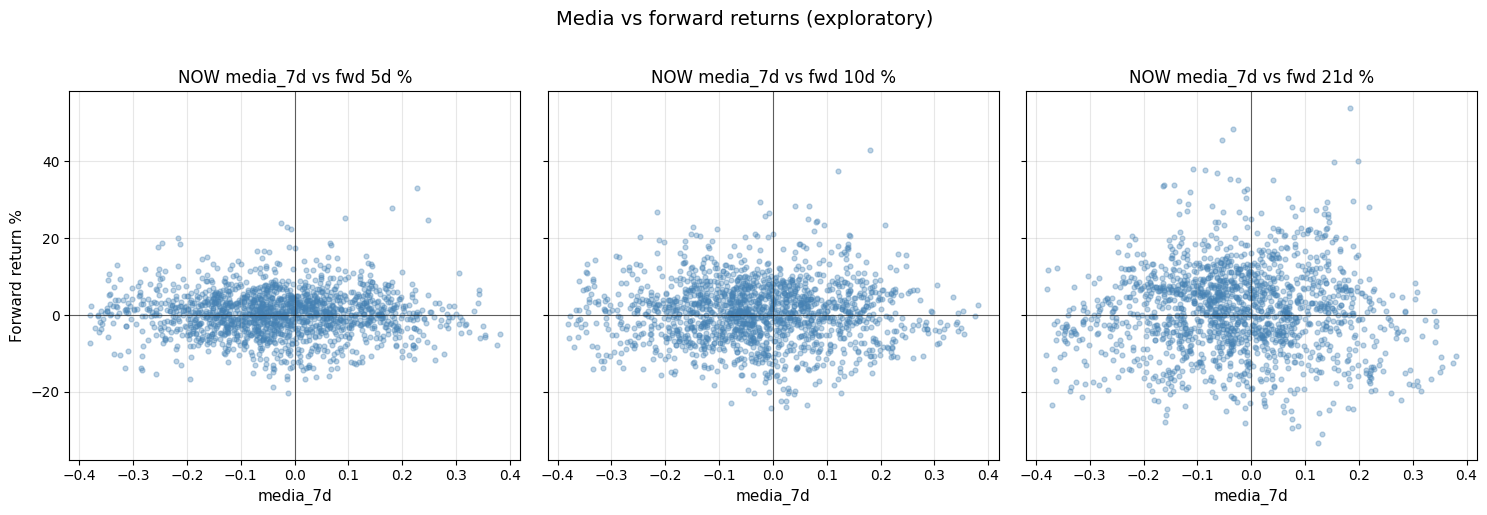

In [12]:
corr_df = media_forward_correlation(frames)
print("Pooled correlation: media score vs forward returns")
print(corr_df.to_string(index=False))

# Simple scatter panels (same clean matplotlib language)
sample = frames.get("NOW")
if sample is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, h in zip(axes, [5, 10, 21]):
        ax.scatter(
            sample["media_7d"],
            sample[f"fwd_{h}d"] * 100,
            s=12,
            alpha=0.35,
            color="steelblue",
        )
        ax.axhline(0, color="black", lw=0.8, alpha=0.6)
        ax.axvline(0, color="black", lw=0.8, alpha=0.6)
        ax.set_title(f"NOW media_7d vs fwd {h}d %", fontsize=12)
        ax.set_xlabel("media_7d")
        if h == 5:
            ax.set_ylabel("Forward return %")
        ax.grid(True, alpha=0.3)
    fig.suptitle("Media vs forward returns (exploratory)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### 9b. Threshold sweep (7d and 30d) on NOW


7d media threshold sweep — NOW
 threshold         variant  final_equity   cagr  max_dd  num_trades  win_rate  fwd_10d_mean
       NaN        baseline     3,001.813  0.183  -0.409          60     0.700         1.927
    -0.300  media_7d>=-0.3     2,820.090  0.172  -0.409          59     0.695         1.774
    -0.150 media_7d>=-0.15     2,274.304  0.134  -0.404          52     0.673         1.788
     0.000   media_7d>=0.0     1,269.905  0.037  -0.330          27     0.593         0.277
     0.100   media_7d>=0.1     1,246.039  0.034  -0.135          12     0.667         2.061
     0.150  media_7d>=0.15       932.707 -0.011  -0.144           5     0.400        -0.248
     0.250  media_7d>=0.25       941.026 -0.009  -0.090           3     0.333        -1.694

30d media threshold sweep — NOW
 threshold          variant  final_equity   cagr  max_dd  num_trades  win_rate  fwd_10d_mean
       NaN         baseline     3,001.813  0.183  -0.409          60     0.700         1.927
    -0.300  me

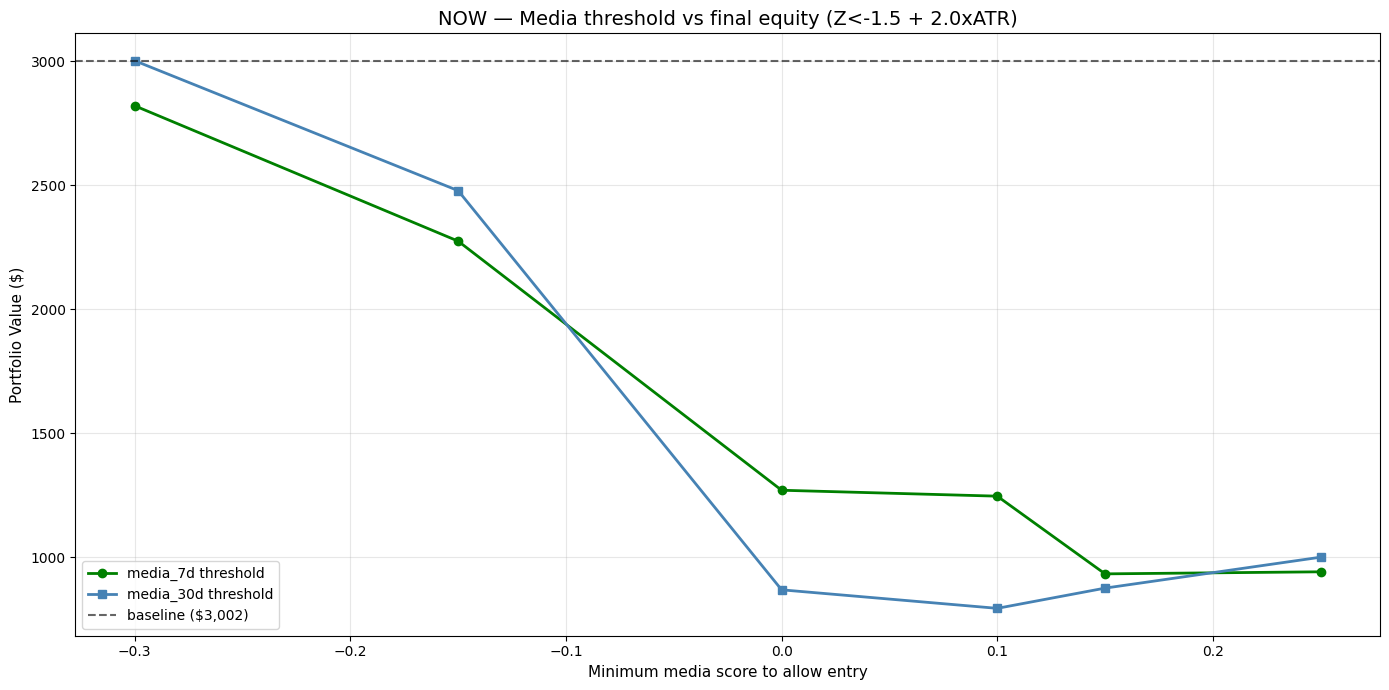

In [13]:
sweep_7 = threshold_sweep(df_now, "NOW", media_col="media_7d")
sweep_30 = threshold_sweep(df_now, "NOW", media_col="media_30d")

print("7d media threshold sweep — NOW")
print(
    sweep_7[
        [
            "threshold",
            "variant",
            "final_equity",
            "cagr",
            "max_dd",
            "num_trades",
            "win_rate",
            "fwd_10d_mean",
        ]
    ].to_string(index=False)
)
print("\n30d media threshold sweep — NOW")
print(
    sweep_30[
        [
            "threshold",
            "variant",
            "final_equity",
            "cagr",
            "max_dd",
            "num_trades",
            "win_rate",
            "fwd_10d_mean",
        ]
    ].to_string(index=False)
)

fig = plot_threshold_sweep(
    sweep_7,
    sweep_30,
    title=f"NOW — Media threshold vs final equity (Z<{Z_ENTRY} + {ATR_MULT}xATR)",
    figsize=(14, 7),
)
plt.show()


### 9c. High vs low volatility regimes


In [14]:
vol_stats = vol_regime_trade_stats(all_trades)
if vol_stats.empty:
    print("Insufficient RV data on trades.")
else:
    print(vol_stats.to_string(index=False))
    focus = vol_stats[
        vol_stats["variant"].isin(
            ["baseline", "media7d_gt0", "media7d_neutral+", "badge7d_not_bad"]
        )
    ]
    if not focus.empty:
        pivot = focus.pivot_table(index="variant", columns="vol_regime", values="avg_ret")
        print("\nAvg trade % by vol regime")
        print(pivot.to_string())


            variant vol_regime   n  win_rate  avg_ret  fwd_10d
     avoid_earnings   high_vol 248     0.653    2.730    2.852
     avoid_earnings    low_vol 250     0.664    1.393    1.980
  badge7d_good_only   high_vol  50     0.620    1.361    1.190
  badge7d_good_only    low_vol  37     0.595    0.168    1.408
    badge7d_not_bad   high_vol 230     0.643    2.281    2.473
    badge7d_not_bad    low_vol 233     0.682    1.728    2.524
           baseline   high_vol 262     0.653    2.644    2.705
           baseline    low_vol 265     0.668    1.554    2.275
  composite_z_media   high_vol 262     0.653    2.644    2.705
  composite_z_media    low_vol 265     0.668    1.554    2.275
       media30d_gt0   high_vol 145     0.628    1.895    2.916
       media30d_gt0    low_vol 146     0.692    1.989    2.703
  media30d_neutral+   high_vol 247     0.644    2.365    2.693
  media30d_neutral+    low_vol 239     0.657    1.422    2.158
        media7d_gt0   high_vol 157     0.643    2.640  

### 9d. Best / worst stocks under media filter


In [15]:
compare = summary[
    summary["variant"].isin(["baseline", "media7d_gt0", "media7d_neutral+"])
]
piv = compare.pivot(index="ticker", columns="variant", values="final_equity")
if "baseline" in piv.columns and "media7d_gt0" in piv.columns:
    piv["lift_media7d_gt0"] = piv["media7d_gt0"] - piv["baseline"]
    piv = piv.sort_values("lift_media7d_gt0", ascending=False)
    print("Stocks ranked by lift when requiring media_7d >= 0")
    print(piv.round(0).to_string())


Stocks ranked by lift when requiring media_7d >= 0
variant  baseline  media7d_gt0  media7d_neutral+  lift_media7d_gt0
ticker                                                            
CRM     1,297.000    1,640.000         1,859.000           342.000
GOOGL   2,095.000    1,775.000         2,256.000          -320.000
CRWD    1,793.000    1,395.000         1,198.000          -398.000
NET     1,924.000    1,316.000         1,078.000          -608.000
PANW    2,798.000    2,137.000         3,130.000          -661.000
MSFT    2,146.000    1,294.000         1,814.000          -852.000
META    3,089.000    2,229.000         3,055.000          -860.000
NOW     3,002.000    1,270.000         2,274.000        -1,732.000
DDOG    4,188.000    2,098.000         3,069.000        -2,090.000
NVDA    4,598.000    2,475.000         3,199.000        -2,122.000


## 10. Equity curves — top variants vs baseline

Charts use the same style as your testing notebooks:
- **Strategy** in green (`lw=2`), final $ in the legend
- **Buy & Hold** in black/gray
- Grid `alpha=0.3`, figsize ~14×7 / 15×8
- Performance print block (Final / CAGR / Max DD / Win rate / last trades)


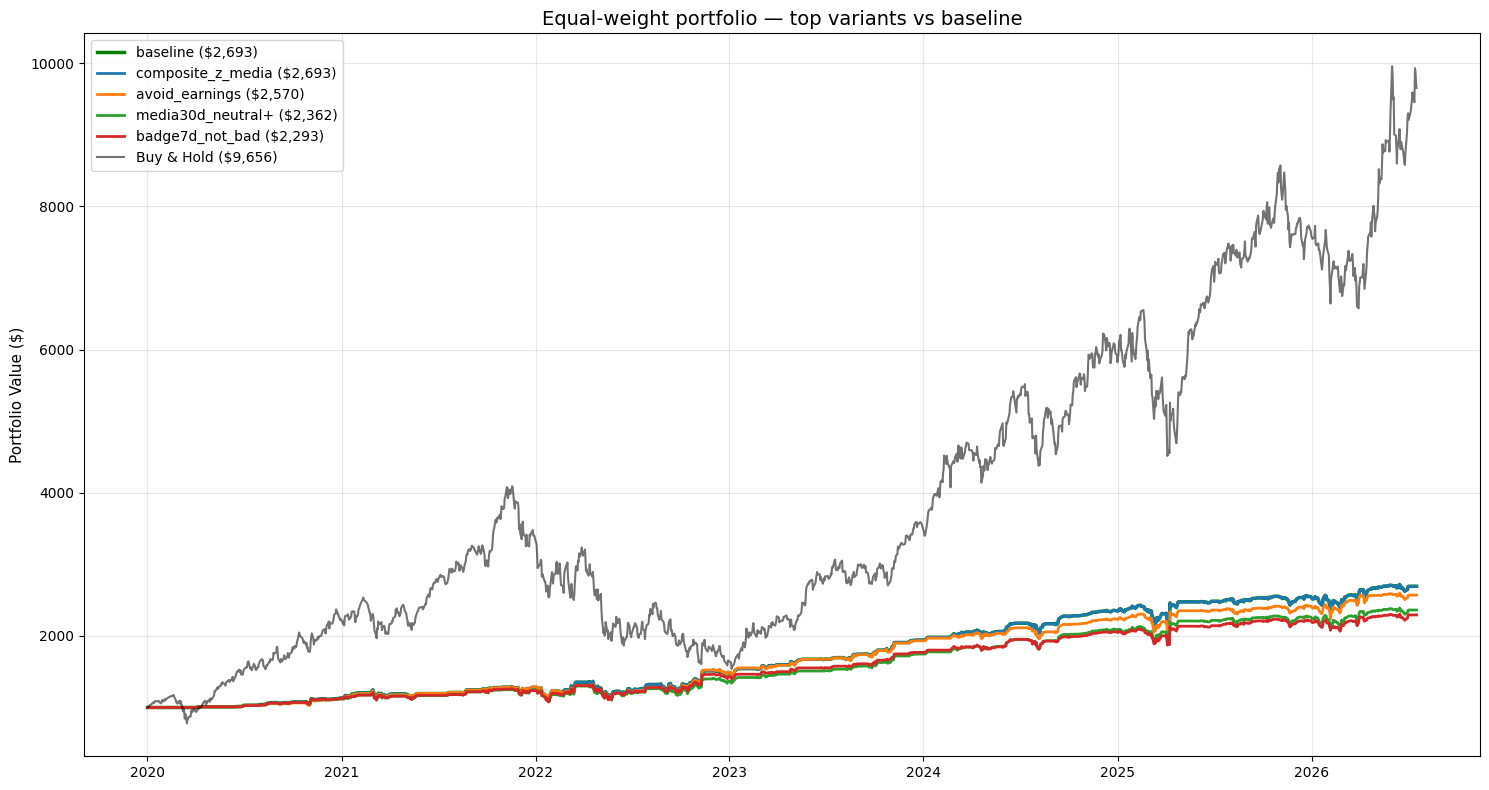

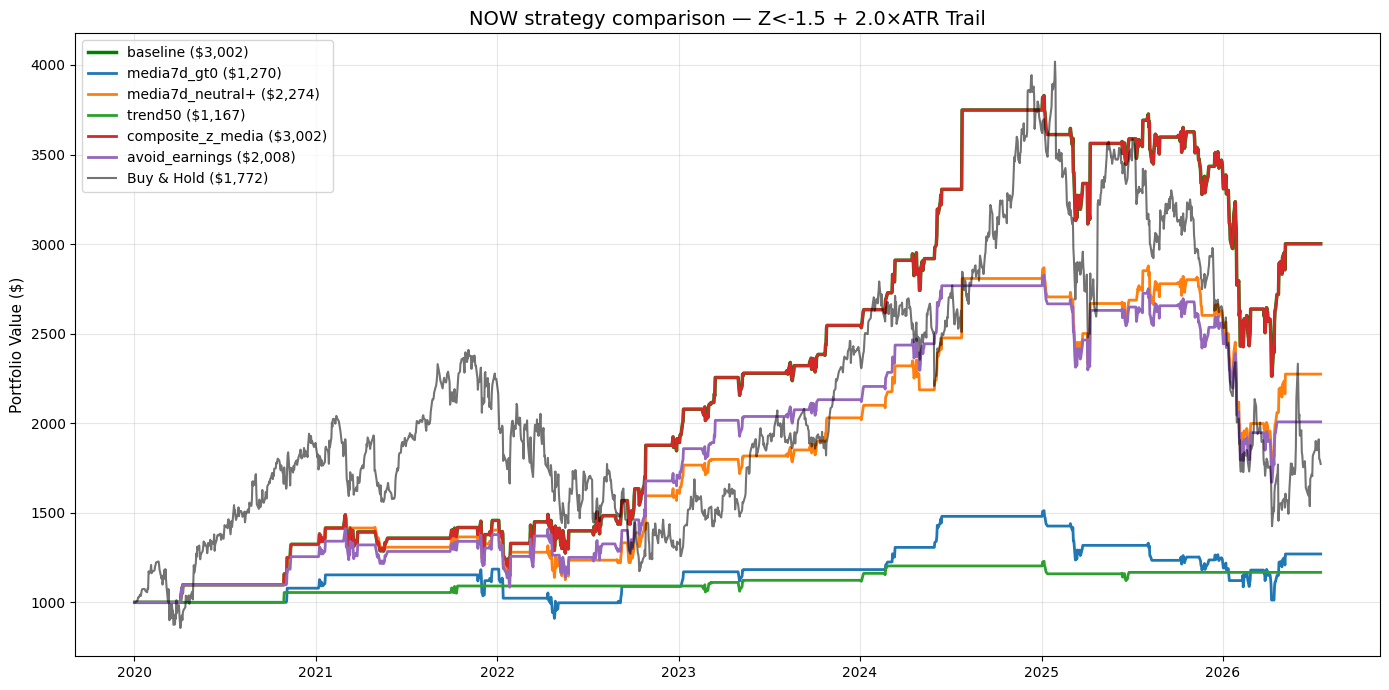

WINNING STRATEGY: Z < -1.5 + 2.0×ATR Trailing Stop
Starting Capital : $1,000
Final Value      : $3,002
Total Return     : 200.2%
CAGR             : 18.3%
Max Drawdown     : -40.9%
Number of Trades : 60

Trade Summary:
  Win rate       : 70.0%
  Avg trade      : 2.12%
  Avg winner     : 6.22%
  Avg loser      : -7.43%
  Avg days held  : 10.9

Last 8 trades:
entry_date  exit_date  entry_price  exit_price  return_pct  days_held
2025-12-15 2026-01-08      153.040     146.190      -4.476         24
2026-01-09 2026-01-14      141.800     134.610      -5.071          5
2026-01-15 2026-01-29      131.170     116.730     -11.009         14
2026-01-30 2026-02-05      117.010     102.630     -12.290          6
2026-02-06 2026-02-26      100.740     109.300       8.497         20
2026-03-24 2026-04-09      104.650      89.810     -14.181         16
2026-04-10 2026-04-20       83.000      99.720      20.145         10
2026-04-23 2026-05-07       84.780      93.590      10.392         14


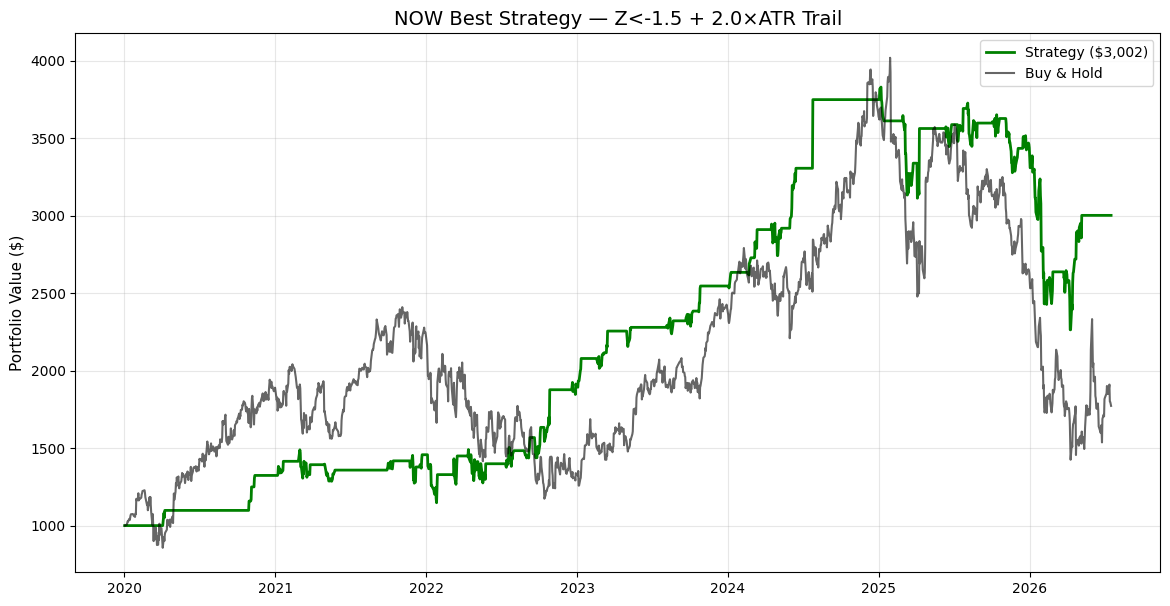

In [16]:
# ============================================================
# EQUITY CURVES — testing-notebook visual language
# ============================================================

top_n = min(5, len(ranking))
top_variants = ranking["variant"].head(top_n).tolist()
if "baseline" not in top_variants:
    top_variants = ["baseline"] + top_variants[: top_n - 1]

# --- Equal-weight portfolio across universe ---
port_curves = {}
for vname in top_variants:
    res_list = []
    filt = variants[vname]
    for t, df in frames.items():
        res_list.append(run_backtest(df, ticker=t, variant=vname, entry_filter=filt))
    port_curves[vname] = portfolio_equal_weight_equity(res_list)

bh_parts = []
for t, df in frames.items():
    bh = START_CAPITAL * (1 + df["daily_ret"].fillna(0)).cumprod()
    bh_parts.append(bh / START_CAPITAL)
port_bh = (
    pd.concat(bh_parts, axis=1).ffill().fillna(1.0).mean(axis=1) * START_CAPITAL
    if bh_parts
    else None
)

fig = plot_variant_equities(
    port_curves,
    title="Equal-weight portfolio — top variants vs baseline",
    buyhold=port_bh,
    figsize=(15, 8),
    highlight="baseline",
)
plt.show()

# --- NOW multi-variant overlay ---
now_curves = {}
focus = [
    "baseline",
    "media7d_gt0",
    "media7d_neutral+",
    "trend50",
    "composite_z_media",
    "avoid_earnings",
]
for vname in focus:
    if vname not in variants:
        continue
    r = run_backtest(df_now, ticker="NOW", variant=vname, entry_filter=variants[vname])
    now_curves[vname] = r.equity
    if vname == "baseline":
        now_base = r

bh_now = START_CAPITAL * (1 + now_base.daily["daily_ret"].fillna(0)).cumprod()
fig = plot_variant_equities(
    now_curves,
    title=f"NOW strategy comparison — Z<{Z_ENTRY} + {ATR_MULT}×ATR Trail",
    buyhold=bh_now,
    figsize=(14, 7),
    highlight="baseline",
)
plt.show()

# --- Dedicated NOW baseline vs B&H (exact test2 snippet) ---
data = now_base.daily
final_value = now_base.metrics["final_equity"]
cagr = now_base.metrics["cagr"]
max_dd = now_base.metrics["max_dd"]
trades_df = now_base.trades
trades = trades_df.to_dict("records") if trades_df is not None else []

print("=" * 60)
print(f"WINNING STRATEGY: Z < {Z_ENTRY} + {ATR_MULT}×ATR Trailing Stop")
print("=" * 60)
print(f"Starting Capital : ${START_CAPITAL:,.0f}")
print(f"Final Value      : ${final_value:,.0f}")
print(f"Total Return     : {(final_value / START_CAPITAL - 1) * 100:.1f}%")
print(f"CAGR             : {cagr * 100:.1f}%")
print(f"Max Drawdown     : {max_dd * 100:.1f}%")
print(f"Number of Trades : {len(trades)}")
print("=" * 60)

if trades_df is not None and len(trades_df) > 0:
    print("\nTrade Summary:")
    print(f"  Win rate       : {(trades_df['return_pct'] > 0).mean() * 100:.1f}%")
    print(f"  Avg trade      : {trades_df['return_pct'].mean():.2f}%")
    print(f"  Avg winner     : {trades_df.loc[trades_df['return_pct'] > 0, 'return_pct'].mean():.2f}%")
    print(f"  Avg loser      : {trades_df.loc[trades_df['return_pct'] <= 0, 'return_pct'].mean():.2f}%")
    print(f"  Avg days held  : {trades_df['days_held'].mean():.1f}")
    print("\nLast 8 trades:")
    show_cols = [
        c
        for c in [
            "entry_date",
            "exit_date",
            "entry_price",
            "exit_price",
            "return_pct",
            "days_held",
        ]
        if c in trades_df.columns
    ]
    print(trades_df[show_cols].tail(8).to_string(index=False))

plt.figure(figsize=(14, 7))
plt.plot(
    data["equity"],
    label=f"Strategy (${final_value:,.0f})",
    color="green",
    lw=2,
)
plt.plot(
    data.index,
    START_CAPITAL * (1 + data["daily_ret"].fillna(0)).cumprod(),
    label="Buy & Hold",
    color="black",
    alpha=0.6,
)
plt.title(f"NOW Best Strategy — Z<{Z_ENTRY} + {ATR_MULT}×ATR Trail", fontsize=14)
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Example trade log (media-aware)

Inspect entries that include media filter reasons — useful when designing live alerts later.


In [ ]:
example_variant = "media7d_gt0"
ex = (
    all_trades[all_trades["variant"] == example_variant].copy()
    if not all_trades.empty
    else pd.DataFrame()
)
if ex.empty:
    print("No trades for", example_variant)
else:
    ex = ex.sort_values("entry_date")
    cols = [
        "ticker",
        "entry_date",
        "exit_date",
        "return_pct",
        "days_held",
        "entry_z",
        "entry_media_7d",
        "entry_media_30d",
        "entry_filter_reason",
        "exit_reason",
        "fwd_10d",
    ]
    cols = [c for c in cols if c in ex.columns]
    print(f"Sample trades — {example_variant} (last 15)")
    print(ex[cols].tail(15).to_string(index=False))


Sample trades — media7d_gt0 (last 15)
ticker entry_date  exit_date  return_pct  days_held  entry_z  entry_media_7d  entry_media_30d entry_filter_reason   exit_reason  fwd_10d
   NOW 2026-03-24 2026-04-09     -14.181         16   -1.693           0.002           -0.007       media7d>=0.00    trail_stop   -6.861
 GOOGL 2026-03-24 2026-03-27      -5.543          3   -2.823           0.181            0.163       media7d>=0.00    trail_stop    9.255
  PANW 2026-03-27 2026-04-02      11.012          6   -2.249           0.033            0.103       media7d>=0.00 mean_revert_z   10.536
  META 2026-03-30 2026-04-08      14.177          9   -1.909           0.027           -0.025       media7d>=0.00 mean_revert_z   23.511
 GOOGL 2026-03-30 2026-04-06       9.686          7   -2.285           0.110            0.151       media7d>=0.00 mean_revert_z   21.722
  DDOG 2026-04-09 2026-04-15      11.085          6   -2.130           0.054            0.087       media7d>=0.00 mean_revert_z   17.324
   

: 

## 12. Plugging in real Alpha Vantage history later

Free AV `NEWS_SENTIMENT` is **not** a full multi-year daily history API (rate limits + short windows). For a true historical study you typically:

1. Archive daily AV pulls over time (recommended), **or**
2. Buy/export a news sentiment history from another vendor, **or**
3. Keep using the simulator for methodology while the live app uses real AV for *current* context only.

### Expected CSV schema for real media

```text
date,media_raw
2024-01-02,0.12
2024-01-03,-0.05
```

Then:

```python
real = pd.read_csv("path/to/NOW_media.csv", parse_dates=["date"]).set_index("date")
df = prepare_frame("NOW", start="2020-01-01", real_media=real)
```

`prepare_frame` rebuilds `media_7d` / `media_30d` / badges from `media_raw`.


In [ ]:
# Template — inactive until you drop CSVs in place
REAL_MEDIA_DIR = ROOT / "studies" / "media_history"

def load_real_media_csv(ticker: str, folder=REAL_MEDIA_DIR):
    path = Path(folder) / f"{ticker}_media.csv"
    if not path.exists():
        return None
    m = pd.read_csv(path, parse_dates=["date"]).set_index("date").sort_index()
    if "media_raw" not in m.columns:
        raise ValueError(f"{path} needs a media_raw column")
    return m

# Example:
# real_now = load_real_media_csv("NOW")
# if real_now is not None:
#     df_real = prepare_frame("NOW", start=START_DATE, real_media=real_now)
#     print(run_backtest(df_real, ticker="NOW", variant="baseline").metrics)

print("Real media folder:", REAL_MEDIA_DIR)
print("Place files like NOW_media.csv there when you start archiving AV pulls.")


## 13. Key Findings & Recommended Avenues

> **Important:** With **simulated** media, numerical “winners” are **methodology demos**, not proof of edge. Re-run after you archive real sentiment before changing live rules.

### How to read this run
1. Compare **baseline** vs media variants on **mean final equity, CAGR, max DD, trade count, win rate, fwd 10d**.
2. Prefer filters that **raise win rate / cut DD** without destroying trade count entirely.
3. Check **per-ticker lift** — media may help Quality names more than high-beta Momentum (or vice versa).
4. Check **vol regimes** — a filter that only helps in high-vol may become a *conditional* rule, not a global gate.
5. Check **correlations** — if media is uncorrelated with forward returns, any improvement is likely from **selection / fewer trades**, which can still be valuable as a discretionary overlay.

### Candidate avenues for live use (research → paper trade)
| Avenue | Idea | Live integration later |
|--------|------|-------------------------|
| A | Soft gate: block entries only when media badge is **Bad** | Sidebar flag / warning on BUY card |
| B | Hard gate: require media_7d ≥ 0 | Opt-in scanner filter |
| C | Earnings blackout ±5d | Calendar overlay (independent of media) |
| D | Composite score for ranking dips | Sort Overview by composite, not binary filter |
| E | Stock-specific: enable media gate only where lift > 0 OOS | Per-ticker config |

### Recommended next steps
1. **Archive daily media** for the universe (even free AV once/day builds a real series over months).
2. Re-run this notebook on **real** `media_raw` and freeze a **validation window** (e.g. last 12 months untouched while you tune earlier data).
3. Only promote a rule to the Streamlit app if it improves **risk-adjusted** stats (Sharpe / DD) without collapsing sample size.
4. Keep media **out of** `data/market.py` entry logic until that bar is cleared — dashboard remains pure Z/ATR.

### Session notes (fill in after you run)
- Best variant by mean final equity: _…_
- Best by Sharpe / DD: _…_
- Names helped / hurt: _…_
- Decision: keep studying / paper trade filter _…_ / no-go


In [ ]:
print("TOP 5 VARIANTS BY MEAN FINAL EQUITY")
print(
    ranking[
        [
            "rank",
            "variant",
            "mean_final",
            "mean_cagr",
            "mean_max_dd",
            "mean_sharpe",
            "total_trades",
        ]
    ]
    .head(5)
    .to_string(index=False)
)
print("\nBASELINE row:")
print(ranking.loc[ranking["variant"] == "baseline"].to_string(index=False))
print("\nDone. Fill in section 13 notes after reviewing charts/tables.")
